<!-- @@COLAB@@ -->
<a href="https://colab.research.google.com/github/laris-co/ajfon-oracle/blob/main/book/notebooks/ch13_lancedb_second_brain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

> **เปิดใน Google Colab** — คลิกป้ายด้านบน รันได้ทันทีบนคลาวด์ฟรี ไม่ต้องติดตั้งอะไรในเครื่อง (เซลล์แรกจะ `pip install` ให้เอง)


# 📘 บทที่ 13 — ก้าวสู่ Production: LanceDB

**เปิดภาค 5 (Production DB)** · คู่กับบทที่ 10 (เรื่องเล่า ARRA ย้าย Chroma→LanceDB)

ChromaDB สอนเราครบทุกแนวคิด (บท 1–12) · ตอนนี้ port ไป **LanceDB** — DB ที่ ARRA ใช้จริงใน production
จะเห็นว่าแนวคิดเดิม**ติดตัวมาหมด** เปลี่ยนแค่ API เล็กน้อย + ได้ของแถมที่ Chroma ไม่มี


In [1]:
import sys
IN_COLAB='google.colab' in sys.modules
if IN_COLAB:
    %pip -q install lancedb sentence-transformers
import lancedb
print('lancedb', lancedb.__version__, '· embedded เหมือน SQLite ✓')


lancedb 0.34.0 · embedded เหมือน SQLite ✓


In [2]:
# ---- embed อัจฉริยะ (Ollama ในเครื่อง / sentence-transformers บน Colab) ----
import urllib.request, json
import numpy as np
def _ok():
    try:
        urllib.request.urlopen('http://localhost:11434/api/tags', timeout=2); return True
    except Exception: return False
if _ok():
    def embed_texts(t):
        req=urllib.request.Request('http://localhost:11434/api/embed',data=json.dumps({'model':'bge-m3','input':list(t)}).encode(),headers={'Content-Type':'application/json'})
        with urllib.request.urlopen(req,timeout=180) as r: V=np.array(json.load(r)['embeddings'])
        return V/np.linalg.norm(V,axis=1,keepdims=True)
    print('embed: Ollama bge-m3 ✓')
else:
    from sentence_transformers import SentenceTransformer
    _m=SentenceTransformer('BAAI/bge-m3')
    def embed_texts(t): return _m.encode(list(t),normalize_embeddings=True)
    print('embed: sentence-transformers ✓')


embed: Ollama bge-m3 ✓


## 1) เปิด second brain ด้วย LanceDB (embedded — โฟลเดอร์ในเครื่อง)


In [3]:
import shutil
shutil.rmtree('./lance_brain', ignore_errors=True)
db = lancedb.connect('./lance_brain')
NOTES = [
    'วิธีสอนนักศึกษาให้เข้าใจ vector search เริ่มจาก cosine similarity',
    'ประชุมกับอาจารย์ฝน เรื่อง workshop วันที่ 26 กรกฎาคม',
    'สูตรกาแฟ cold brew กาแฟ 100g น้ำ 1L แช่ 18 ชั่วโมง',
    'งานวิจัย embedding หลายภาษา bge-m3 เหมาะกับภาษาไทย',
    'รายการซื้อของ นม ไข่ ขนมปัง กาแฟดริป',
]
V = embed_texts(NOTES)
tbl = db.create_table('second_brain', data=[
    {'id': f'n{i}', 'text': t, 'folder': f, 'vector': v.tolist()}
    for i,(t,f,v) in enumerate(zip(NOTES, ['teaching','meetings','recipes','teaching','personal'], V))
])
print('โน้ตใน LanceDB:', tbl.count_rows())


โน้ตใน LanceDB: 5


## 2) ค้นด้วยความหมาย — ระบุ cosine ชัด (เหมือน ARRA lancedb.ts)


In [4]:
def search(q, k=2, **kw):
    qv = embed_texts([q])[0].tolist()
    return tbl.search(qv).distance_type('cosine').limit(k).to_pandas(**kw)

for q in ['นัดหมายกับใครบ้าง', 'อยากสอนเรื่อง AI ค้นหา']:
    r = search(q)
    print(f'Q: {q}')
    for _, row in r.iterrows():
        print(f"   {1-row['_distance']:+.3f}  {row['text'][:48]}")
    print()


Q: นัดหมายกับใครบ้าง
   +0.534  ประชุมกับอาจารย์ฝน เรื่อง workshop วันที่ 26 กรก
   +0.452  รายการซื้อของ นม ไข่ ขนมปัง กาแฟดริป



Q: อยากสอนเรื่อง AI ค้นหา
   +0.658  วิธีสอนนักศึกษาให้เข้าใจ vector search เริ่มจาก 
   +0.507  ประชุมกับอาจารย์ฝน เรื่อง workshop วันที่ 26 กรก



## 3) filter + vector พร้อมกัน (SQL where — เหมือน metadata filter บทที่ 3)


In [5]:
qv = embed_texts(['การสอน'])[0].tolist()
r = tbl.search(qv).distance_type('cosine').where("folder = 'teaching'").limit(5).to_pandas()
print('ค้น "การสอน" เฉพาะ folder=teaching:')
for _, row in r.iterrows():
    print(f"   → {row['text'][:50]}")


ค้น "การสอน" เฉพาะ folder=teaching:
   → วิธีสอนนักศึกษาให้เข้าใจ vector search เริ่มจาก co
   → งานวิจัย embedding หลายภาษา bge-m3 เหมาะกับภาษาไทย


## ✅ วัดผลตัวเอง #13


In [6]:
r = search('นัดหมายกับใครบ้าง', k=1)
assert 'ประชุม' in r.iloc[0]['text'], 'ต้องเจอโน้ตประชุม'
r2 = tbl.search(embed_texts(['การสอน'])[0].tolist()).where("folder = 'teaching'").limit(5).to_pandas()
assert all(r2['folder']=='teaching'), 'filter ต้องไม่รั่ว'
assert tbl.count_rows()==5
print('✅ ผ่าน! แนวคิดเดิมจากบท 1–3 ทำงานบน LanceDB — เปลี่ยนแค่ API (.search().where())')


✅ ผ่าน! แนวคิดเดิมจากบท 1–3 ทำงานบน LanceDB — เปลี่ยนแค่ API (.search().where())


## 📊 เห็นภาพ — LanceDB คะแนน top-1 (query ไทย)


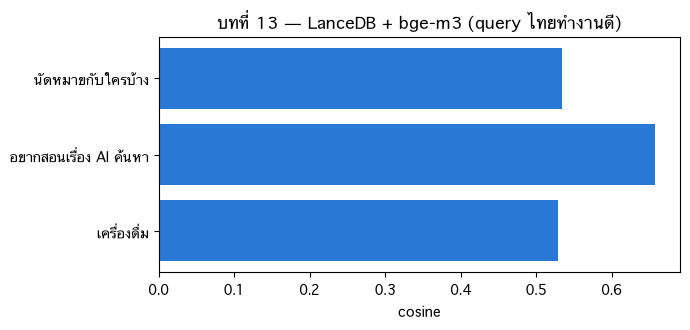

In [7]:
# @@VIZ@@
import matplotlib, matplotlib.pyplot as plt
from matplotlib import font_manager as _fm
_av={f.name for f in _fm.fontManager.ttflist}
for _f in ['Thonburi','Loma','Sarabun','Noto Sans Thai','TH Sarabun New']:
    if _f in _av: matplotlib.rcParams['font.family']=_f; break
matplotlib.rcParams['axes.unicode_minus']=False
qs=['นัดหมายกับใครบ้าง','อยากสอนเรื่อง AI ค้นหา','เครื่องดื่ม']; sc=[]
for q in qs:
    r=tbl.search(embed_texts([q])[0].tolist()).distance_type('cosine').limit(1).to_pandas()
    sc.append(1-r.iloc[0]['_distance'])
plt.figure(figsize=(7,3.4)); plt.barh(qs[::-1],sc[::-1],color='#2a78d6')
plt.title('บทที่ 13 — LanceDB + bge-m3 (query ไทยทำงานดี)'); plt.xlabel('cosine')
plt.tight_layout(); plt.show()


## LanceDB ต่างจาก Chroma ตรงไหน (ที่จะเห็นบทถัดไป)

| | ChromaDB (สอน) | LanceDB (production) |
|---|---|---|
| ค้น semantic | ✓ | ✓ |
| metadata filter | `where={...}` dict | `.where("SQL")` |
| **keyword/FTS** | ต้องเขียน BM25 เอง (บท 7) | **native ในตัว** → บทที่ 14 |
| **versioning** | ✗ | **time-travel ในตัว** → บทที่ 15 |
| runtime | Python-first | Rust core (ฝัง Bun/TS ได้ = ARRA) |

**บทต่อไป:** `ch14_lancedb_hybrid_native.ipynb` — FTS + vector ในเครื่องเดียว ไม่ต้องเขียน BM25 เอง
